In [1]:
!pip install focal-loss

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 5.8 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, applications, callbacks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss
import gc

2026-01-01 15:52:59.791767: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767282780.000239      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767282780.056029      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
SEED = 24520152

In [4]:
tf.keras.utils.set_random_seed(SEED)

In [5]:
TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [6]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [7]:
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [8]:
MODEL1_DIR = '/kaggle/input/densenet121-ensemble/DenseNet121_Ensemble'
MODEL1_DIR

'/kaggle/input/densenet121-ensemble/DenseNet121_Ensemble'

In [9]:
preprocess_fn1 = applications.densenet.preprocess_input

In [10]:
MODEL2_DIR = '/kaggle/input/resnet50-ensemble/ResNet50_Ensemble'
MODEL2_DIR

'/kaggle/input/resnet50-ensemble/ResNet50_Ensemble'

In [11]:
preprocess_fn2 = applications.resnet.preprocess_input

In [12]:
MODEL3_DIR = '/kaggle/input/mobilenet-ensemble/MobileNet_Ensemble'
MODEL3_DIR

'/kaggle/input/mobilenet-ensemble/MobileNet_Ensemble'

In [13]:
preprocess_fn3 = applications.mobilenet.preprocess_input

In [14]:
MODEL4_DIR = '/kaggle/input/xception-ensemble/Xception_Ensemble'
MODEL4_DIR

'/kaggle/input/xception-ensemble/Xception_Ensemble'

In [15]:
preprocess_fn4 = applications.xception.preprocess_input

In [16]:
def get_validation_fold(k, train_dir=TRAIN_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=24520152):
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )
    
    AUTOTUNE = tf.data.AUTOTUNE

    return val_ds

In [17]:
def tta_augmentation(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img

In [18]:
def tta_predict(model, preprocess_fn, ds, tta_rounds=5):
    AUTOTUNE = tf.data.AUTOTUNE
    
    val_ds = ds.map(lambda image, label: (preprocess_fn(image), label)).prefetch(AUTOTUNE)
    preds = [model.predict(val_ds)]

    for _ in range(tta_rounds):
        tta_ds = ds.map(lambda image, label: (tta_augmentation(image), label)).prefetch(AUTOTUNE)
        tta_ds = tta_ds.map(lambda image, label: (preprocess_fn(image), label)).prefetch(AUTOTUNE)
        preds.append(model.predict(tta_ds))

    preds = np.array(preds)
    return np.mean(preds, axis=0)

In [19]:
def test(val_ds, fold_k, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    model1 = tf.keras.models.load_model(os.path.join(MODEL1_DIR, f'DenseNet121_block_2_fold_{fold_k}.keras'))
    model2 = tf.keras.models.load_model(os.path.join(MODEL2_DIR, f'ResNet50_block_1_fold_{fold_k}.keras'))
    model3 = tf.keras.models.load_model(os.path.join(MODEL3_DIR, f'MobileNet_block_1_fold_{fold_k}.keras'))
    model4 = tf.keras.models.load_model(os.path.join(MODEL4_DIR, f'Xception_block_2_fold_{fold_k}.keras'))

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    pred1 = tta_predict(model1, preprocess_fn1, val_ds)
    pred2 = tta_predict(model2, preprocess_fn2, val_ds)
    pred3 = tta_predict(model3, preprocess_fn3, val_ds)
    pred4 = tta_predict(model4, preprocess_fn4, val_ds)
    ensemble_pred = (pred1 + pred2 + pred3 + pred4) / 4.0
    y_pred = np.argmax(ensemble_pred, axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — Ensemble DenseNet121 - ResNet50 - Xception - MobileNet')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    acc = accuracy_score(y_true, y_pred)

    del model1, model2, model3, model4, val_ds, y_true, pred1, pred2, pred3, pred4, ensemble_pred, y_pred, cm
    tf.keras.backend.clear_session()
    gc.collect()

    return acc

In [20]:
acc = []

Fold: 1
Found 542 files belonging to 3 classes.


I0000 00:00:1767282795.638626      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1767282818.690779     118 service.cc:148] XLA service 0x7cffcc003540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767282818.691604     118 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767282819.963791     118 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/17 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

I0000 00:00:1767282829.187477     118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/17 ━━━━━━━━━━━━━━━━━━━━ 28s 867ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 343ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 354ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step
                  precision    r

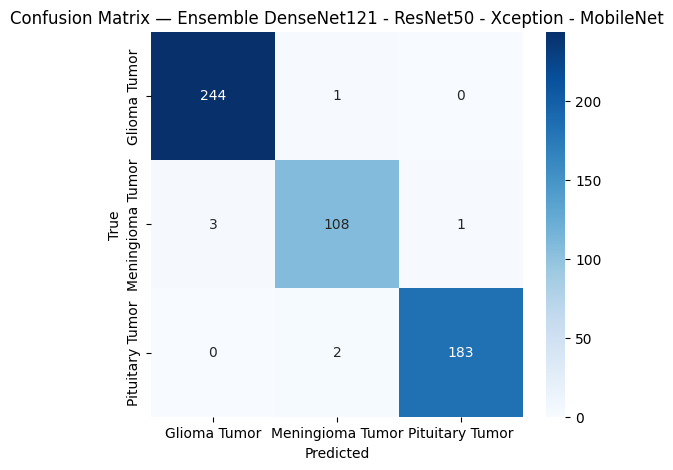

Fold: 2
Found 679 files belonging to 3 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 648ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 248ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step
22/22 ━━━━━━━━━━━━━━━━━━━

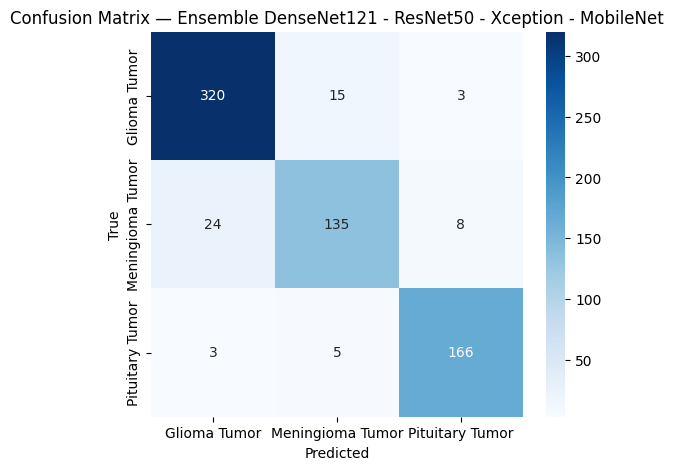

Fold: 3
Found 572 files belonging to 3 classes.
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 825ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 325ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 392ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 

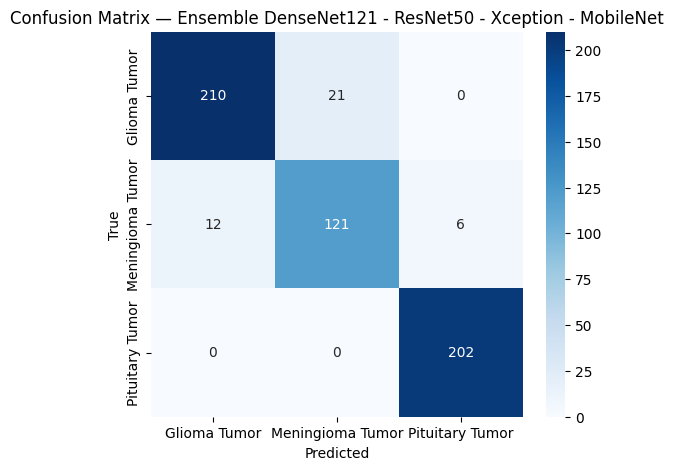

Fold: 4
Found 628 files belonging to 3 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 735ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 287ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 308ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step
20/20 ━━━━━━━━━━━━━━━━━━━

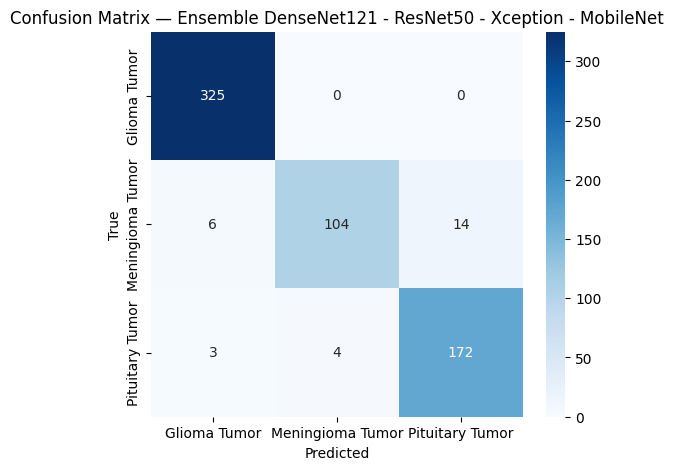

Fold: 5
Found 643 files belonging to 3 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 643ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 

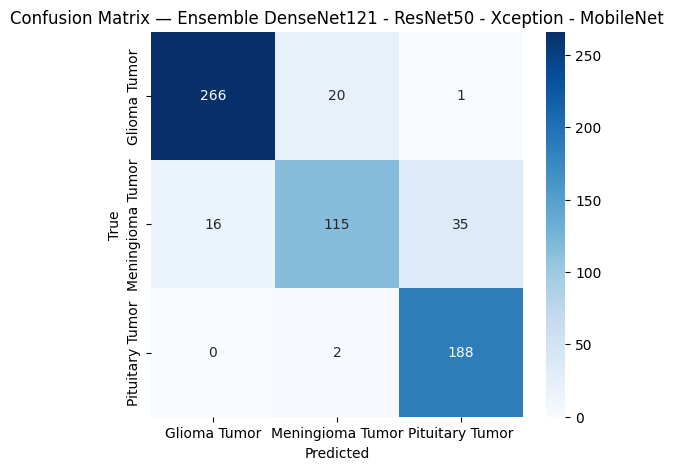

In [21]:
for fold_k in range(1, 6):
    print(f'Fold: {fold_k}')
    
    val_ds = get_validation_fold(fold_k)
    acc.append(test(val_ds, fold_k))

    del val_ds
    tf.keras.backend.clear_session()
    gc.collect()

In [22]:
print(f'Accuracy: {np.mean(acc) * 100:.2f}%')

Accuracy: 93.51%
